

---


#**데이터 분석 과정**
1. 문제정의 : 가치가있는 문제를 찾고 분석의 목적 설정, 분석대상에대한 전문 지식 쌓기
2. 데이터 수집: 분석에 필요한 데이터 확보
3. 데이터 전처리: 데이터셋 확인, 중복값 및 결측값 제거, 이상치 처리 등
4. 데이터 분석: 모델링이 완료된 데이터를 수학적 기법으로 통계분석, 인공지능 모델학습을 통한 예측
및 분류, 시각화
5. 해석 및 활용: 분석결과를 설득력있게 정리 및 전달


---



#**[문제 정의]**

##1. 탐구 주제명

엘니뇨 라니냐와 태풍의 관계

##2. 탐구 배경 및 필요성

*  탐구 배경 : 태풍의 형성 및 발달 조건중 '높은 바다 수온'이 있다. 이때 지구온난화로 생긴 이상현상중 해수면 온도가 평년보다 높은 현상인 엘니뇨와 평년보다 낮은 현상인 라니냐가 태풍의 세기에 주는 영향을 알아본다.
*  필요성 : 사람들이 지구온난화로 인해 발생한 엘니뇨로 인해 태풍이 강해져 큰 피해를 남길 수 있다는 사실을 알게하고 경각심을 가지게 한다.

##3. 개념정리

*   엘니뇨 :  열대 동태평양과 중태평양의 해수면온도가 평상시보다 높은 상태로 수개월이상 지속되는 현상
*   라니냐 : 열대 동태평양과 중태평양의 해수면온도가 평상시보다 낮은 상태로 수개월이상 지속되는 현상
*   태풍의 최저기압 : 태풍의 중심기압 값 중에서 값이 가장 낮았던 값을 의미하며 낮을수록 강한 태풍임을 뜻한다.
*   태풍의 최대풍속 : 태풍의 풍속 값 중에서 값이 가장 높았던 값을 의미하며 높을수록 강한 태풍임을 뜻한다.

#**[데이터 수집]**

##1. 활용 데이터

수집할 데이터는 1990년 부터 2023년 까지의 태풍들 각각의 최저기압과 최대풍속이며, 이는 모두 공공 데이터로 공개되고 있다.

▶ 각 태풍의 최저가압과 최대풍속 데이터 찾기

* 대한민국 기상청 과거 태풍 정보에서 각 태풍이 활동했을때의 최저기압과 최대풍속을 가져온다.
* 도움자료 https://www.weather.go.kr/w/typhoon/typ-history.do
* 19990년 1호 태풍부터 2023.09.08 기준 마지막 데이터인 2023년 12호 태풍까지의 데이터를 모두 가져와 파일 명 'TY_1990-2023.csv’로 파일을 만든다.

##2. 라이브러리 불러오기

In [1]:
# pandas, numpy 및 pyplot 라이브러리를 불러온다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 레티나 디스플레이를 지원하도록 해서 한글이 흐릿하게 보이는 현상 개선
%config InlineBackend.figure_format = 'retina'

#한글 나눔 폰트 사용설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

 #해당 폰트를 기본 폰트가 되도록 설정
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 18 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

## 3. 파일 읽어오기

In [2]:
from google.colab import files
myfile = files.upload()

# 업로드한 'seoul_rent_bike.csv' 파일을 df_ty에 저장한다.
# 인코딩을 cp949로 할 경우 오류가 생겨 UTF8로 대체
df_ty = pd.read_csv('TY_1990-2023.csv',encoding='UTF8')

Saving TY_1990-2023.csv to TY_1990-2023.csv


##4. 데이터셋 일부 내용 확인

In [ ]:
# df_ty의 5개 데이터를 출력한다
df_ty.head()

,태풍번호,태풍명,최저 기압(hpa),최대풍속(10분 평균 m/s)
0,202312,기러기(KIROGI),992,23
1,202311,하이쿠이(HAIKUI),955,40
2,202310,담레이(DAMREY),985,27
3,202309,사올라(SAOLA),920,53
4,202308,도라(DORA),975,32


#**[탐색적 데이터 분석]**

##1. 데이터셋 통계 정보 확인

In [3]:
df_ty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   태풍번호              839 non-null    int64 
 1   태풍명               839 non-null    object
 2   최저 기압(hpa)        839 non-null    int64 
 3   최대풍속(10분 평균 m/s)  839 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 26.3+ KB


총 4개의 속성이 있으며 ‘태풍명'은 문자형, ‘태풍번호', '최저기압', '최대풍속'은 정수형 데이터로 불러 온 것을 확인할 수 있다. 데이터가 모두 839개로 일치한 것을 통해 결측치가 없다는 것을 알 수 있다.

In [4]:
df_ty.describe()

,태풍번호,최저 기압(hpa),최대풍속(10분 평균 m/s)
count,839.000000,839.000000,839.00000
mean,200602.918951,964.203814,34.54112
std,994.914456,28.223032,12.09254
min,199001.000000,890.000000,17.00000
25%,199708.500000,940.000000,23.00000
50%,200604.000000,970.000000,33.00000
75%,201508.500000,990.000000,44.00000
max,202312.000000,1008.000000,62.00000


총 839건의 데이터가 결측치가 없이 있으며 describe( ) 함수에서 수치형 데이터의 통계치가 표시되므로 통계치를 확인할 수 있다. 이때 '태풍번호'는 1990년 1호 태풍부터 2023년 12호 태풍까지 약 33년간의 태풍이 있는 것을 확인 할 수 있고 최저기압의 최대값이 1008hPa, 최솟값이 890hPa, 최대풍속의 최대값이 62m/s, 최솟값이 17m/s로 차이가 큰 것을 알 수 있다.

##2. 데이터 전처리

In [6]:
#필요한 자료 추출
df_ty2 = df_ty[['태풍번호','최저 기압(hpa)','최대풍속(10분 평균 m/s)']]
df_ty2

,태풍번호,최저 기압(hpa),최대풍속(10분 평균 m/s)
0,202312,992,23
1,202311,955,40
2,202310,985,27
3,202309,920,53
4,202308,975,32
...,...,...,...
834,199005,970,33
835,199004,980,28
836,199003,965,36
837,199002,998,18


In [7]:
# 열명 단순화
df_ty2.columns=['태풍번호','최저기압','최대풍속']

# 새로운 '구분' 열을 추가하고 초기값을 설정한다.
df_ty2['구분'] = ''

# 태풍 번호를 이용하여 '구분'값을 엘니뇨가 발생한 년도에는 'E'를, 라니냐가 발생했을 때에는 'L'을, 그 외에는 'N'을 입력한다.
df_ty2.loc[df_ty['태풍번호'] >= 202300, '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 201800) & (df_ty['태풍번호'] <= 202000), '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 201400) & (df_ty['태풍번호'] <= 201600), '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 200900) & (df_ty['태풍번호'] <= 201000), '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 200500) & (df_ty['태풍번호'] <= 200600), '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 200200) & (df_ty['태풍번호'] <= 200300), '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 199700) & (df_ty['태풍번호'] <= 199800), '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 199100) & (df_ty['태풍번호'] <= 199200), '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 198600) & (df_ty['태풍번호'] <= 198700), '구분'] = 'E'
df_ty2.loc[(df_ty['태풍번호'] >= 202000) & (df_ty['태풍번호'] < 202300), '구분'] = 'L'
df_ty2.loc[(df_ty['태풍번호'] >= 201000) & (df_ty['태풍번호'] <= 201200), '구분'] = 'L'
df_ty2.loc[(df_ty['태풍번호'] >= 200700) & (df_ty['태풍번호'] <= 200800), '구분'] = 'L'
df_ty2.loc[(df_ty['태풍번호'] >= 200500) & (df_ty['태풍번호'] <= 200600), '구분'] = 'L'
df_ty2.loc[(df_ty['태풍번호'] >= 199900) & (df_ty['태풍번호'] <= 200000), '구분'] = 'L'
df_ty2.loc[(df_ty['태풍번호'] >= 199500) & (df_ty['태풍번호'] <= 199600), '구분'] = 'L'
df_ty2['구분']=df_ty2['구분'].replace('','N')


In [8]:
df_ty2

,태풍번호,최저기압,최대풍속,구분
0,202312,992,23,E
1,202311,955,40,E
2,202310,985,27,E
3,202309,920,53,E
4,202308,975,32,E
...,...,...,...,...
834,199005,970,33,N
835,199004,980,28,N
836,199003,965,36,N
837,199002,998,18,N


엘니뇨와 라니냐, 그리고 둘 다 아닐때를 구별해주는 '구분'을 추가해 엘니뇨, 라니냐, 둘 다 아닐때의 값을 따로 파악할 수 있게 만들어 준다.

##3. 데이터 분석

In [9]:
df_ty2.groupby('구분').mean()['최저기압']

구분
E    959.932735
L    970.472081
N    963.529833
Name: 최저기압, dtype: float64

엘니뇨, 라니냐, 둘 다 아닐때의 최저기압의 평균을 분석했을때 엘니뇨가 약 960hPa로 가장 낮고 둘 다 아닐때가 약 964hPa이며 라니냐가 약 970hPa로 가장 높다. 이때 최저기압은 낮을수록 태풍이 강하다는 뜻이므로 엘니뇨일때 가장 강하고 라니냐일때 약하다는 것을 알 수 있다.

In [10]:
df_ty2.groupby('구분').mean()['최대풍속']

구분
E    36.331839
L    32.030457
N    34.768496
Name: 최대풍속, dtype: float64

엘니뇨, 라니냐, 둘 다 아닐때의 최대풍속의 평균을 분석했을때 엘니뇨가 약 36m/s로 가장 높고 둘 다 아닐때가 약 35m/s이며 라니냐가 약 32m/s로 가장 낮다. 이때 최대풍속은 높을수록 태풍이 강하다는 뜻이므로 엘니뇨일때 가장 강하고 라니냐일때 약하다는 것을 알 수 있다.

##4. 시각화

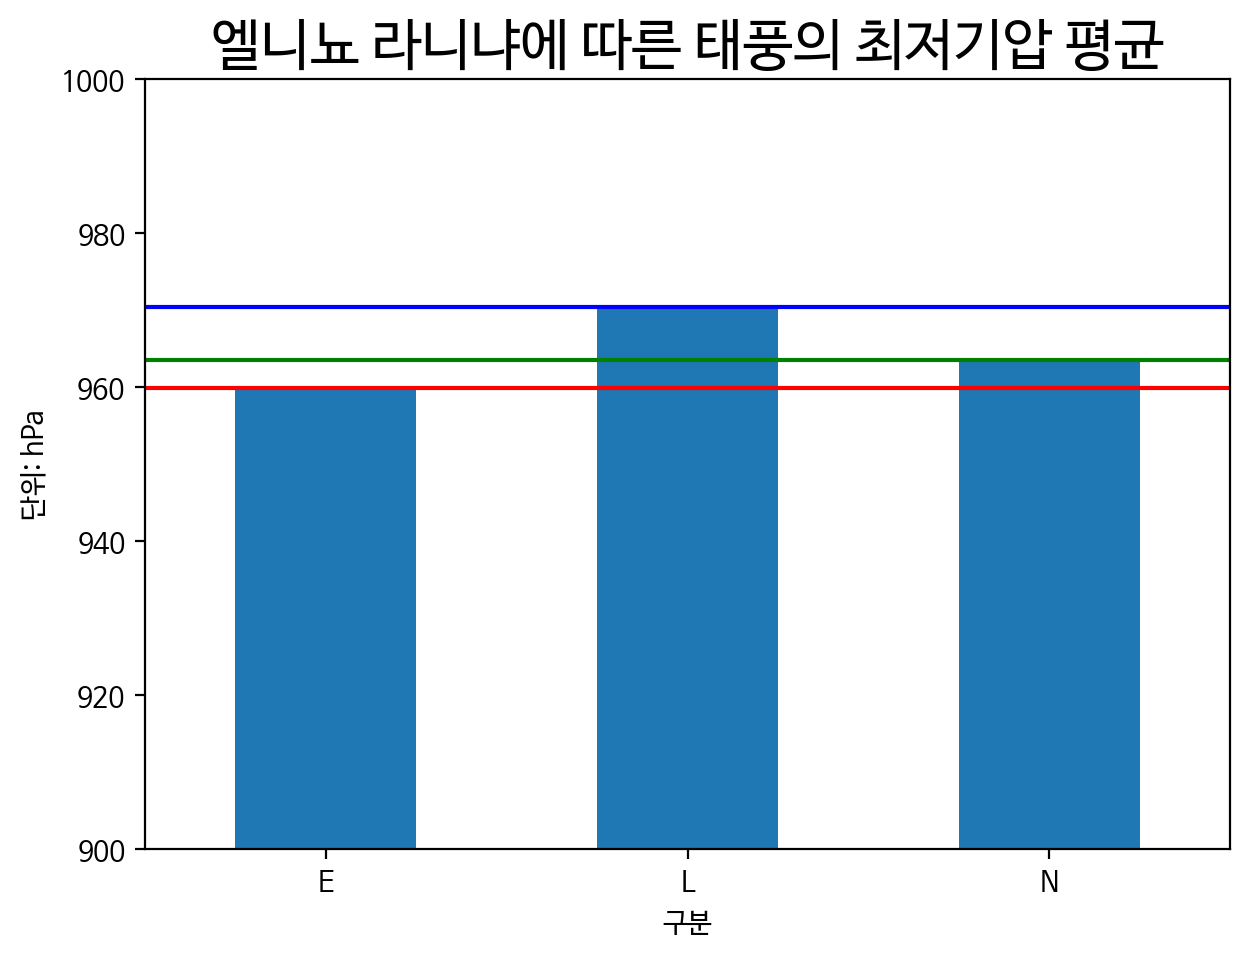

In [30]:
# pandas 라이브러리의 plot( ) 메서드를 이용해서
# 구분에 따른 ‘최저기압’ 평균을 막대그래프로 표시한다.
# 이때 최저기압이 '낮을수록' 강한 태풍임에 유의한다.
df_ty2.groupby('구분').mean()['최저기압'].plot(figsize=(7,5),kind='bar',rot=0)

# 제목, 축 제목 추가
plt.title('엘니뇨 라니냐에 따른 태풍의 최저기압 평균', fontsize=20)
plt.ylabel('단위: hPa')

# y축의 값을 900에서 1000으로 설정하여 차이가 잘 보이도록 한다.
plt.ylim([900, 1000])

#비교를 위한 선을 추가한다.
plt.axhline(y=959.932735,color='r')
plt.axhline(y=970.472081,color='b')
plt.axhline(y=963.529833,color='g')

plt.show()

막대그래프를 이용해서 최저기압이 엘니뇨일 때 가장 낮고 라니냐일 때 가장 높은 것을 쉽게 확인 할 수 있다.

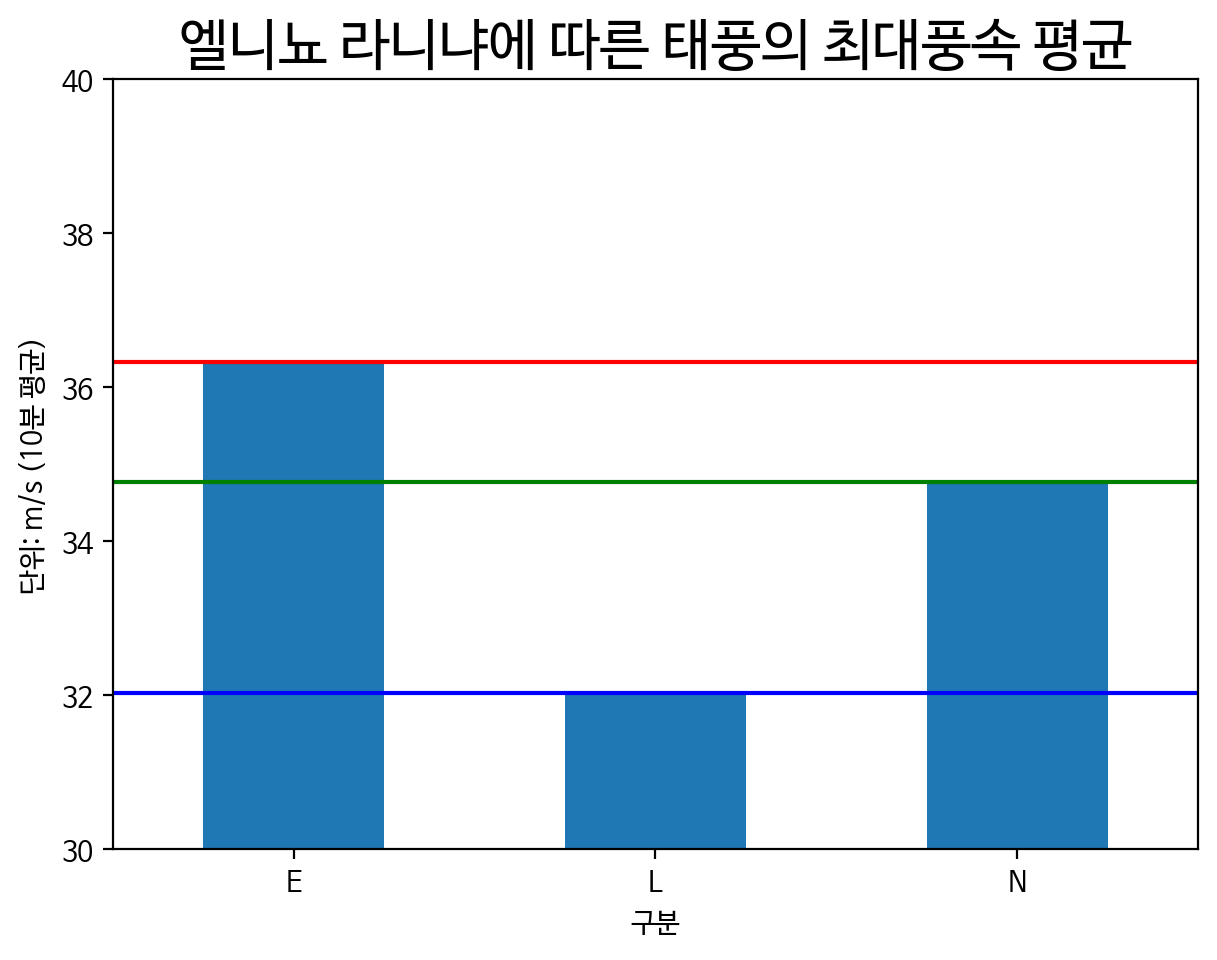

In [31]:
# pandas 라이브러리의 plot( ) 메서드를 이용해서
# 구분에 따른 ‘최대풍속’ 평균을 막대그래프로 표시한다.
# 이때 최대풍속이 '높을수록' 강한 태풍임에 유의한다.
df_ty2.groupby('구분').mean()['최대풍속'].plot(figsize=(7,5),kind='bar',rot=0)

# 제목, 축 제목 추가
plt.title('엘니뇨 라니냐에 따른 태풍의 최대풍속 평균', fontsize=20)
plt.ylabel('단위: m/s (10분 평균)')

# y축의 값을 30에서 40으로 설정하여 차이가 잘 보이도록 한다.
plt.ylim([30, 40])

#비교를 위한 선을 추가한다.
plt.axhline(y=36.331839,color='r')
plt.axhline(y=32.030457,color='b')
plt.axhline(y=34.768496,color='g')

plt.show()

막대그래프를 이용해서 최대풍속이 엘니뇨일 때 가장 높고 라니냐일 때 가장 낮은 것을 쉽게 확인 할 수 있다.

#**[결론 및 제언]**

데이터 분석을 통해 평소보다 엘니뇨일때 태풍이 평균적으로 강해지고 라니냐일때 태풍이 평균적으로 약해진다는 것을 알 수 있다. 지구온난화의 이상현상으로 인해 엘니뇨가 일어난다면 더 강한 태풍이 만들어 질 확률이 크고 그 태풍은 다른 태풍에 비해 큰 피해를 남길 수 있다, 특히 엘리뇨가 매우 강한 현상, 즉 '슈퍼 엘니뇨'일때는 슈퍼 태풍이 발생하여 역대 기록을 경신하며 막대한 피해를 남길 수 있다. 우리는 이를통해 지구온난화가 태풍을 더 강하게 만들게 되며 이로인해 자신, 가족, 이웃, 그리고 같은 나라의 국민들이 큰 피해를 입게 될 수 있다는 점을 기억하고, 경각심을 갖으며 피해를 줄이기 위해서는 이산화탄소의 배출 줄이기, 쓰레기 재활용 등 여러가지 방법을 실천하여 지구온난화의 진행을 최소화 시키는데 노력해야 한다는 것을 기억해야 한다.

[참고]
태풍에 대한 명명권은 일본 기상청(JMA)에 있어 한국 기상청(KMA)에서 데이터를 가져온 이 데이터 분석 결과는 국제적으로 인정을 받기 힘들 수도 있으며 합동태풍경보센터(JTWC)와는 풍속 측정 기준이 달라 (JTWC : 1분평균 / KMA, JMA : 10분평균) 데이터를 어디서 가져오냐에 따라 결과에 차이가 생길 수 있다.